In [59]:
# !pip install xgboost lightgbm catboost

# Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


In [61]:
df= pd.read_csv('stroke.csv')

In [62]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0.5,0.816895,0.0,1.0,1.0,0.50,1.0,0.801265,0.301260,0.333333,1
1,0.0,0.743652,0.0,0.0,1.0,0.75,0.0,0.679023,0.212981,0.666667,1
2,0.5,0.975586,0.0,1.0,1.0,0.50,0.0,0.234512,0.254296,0.666667,1
3,0.0,0.597168,0.0,0.0,1.0,0.50,1.0,0.536008,0.276060,1.000000,1
4,0.0,0.963379,1.0,0.0,1.0,0.75,0.0,0.549349,0.156930,0.666667,1


In [63]:
df.shape

(9722, 11)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9722 entries, 0 to 9721
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             9722 non-null   float64
 1   age                9722 non-null   float64
 2   hypertension       9722 non-null   float64
 3   heart_disease      9722 non-null   float64
 4   ever_married       9722 non-null   float64
 5   work_type          9722 non-null   float64
 6   Residence_type     9722 non-null   float64
 7   avg_glucose_level  9722 non-null   float64
 8   bmi                9722 non-null   float64
 9   smoking_status     9722 non-null   float64
 10  stroke             9722 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 835.6 KB


In [65]:
X=df.drop('stroke',axis =1)
y= df[['stroke']]

In [66]:
X.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,0.5,0.816895,0.0,1.0,1.0,0.50,1.0,0.801265,0.301260,0.333333
1,0.0,0.743652,0.0,0.0,1.0,0.75,0.0,0.679023,0.212981,0.666667
2,0.5,0.975586,0.0,1.0,1.0,0.50,0.0,0.234512,0.254296,0.666667
3,0.0,0.597168,0.0,0.0,1.0,0.50,1.0,0.536008,0.276060,1.000000
4,0.0,0.963379,1.0,0.0,1.0,0.75,0.0,0.549349,0.156930,0.666667


In [67]:
y.head()

,stroke
0,1
1,1
2,1
3,1
4,1


In [68]:
# Split into Input and Output Elements
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                   test_size= 0.20, random_state=100, stratify=y)

In [69]:
print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (7777, 10)  y_train =  (7777, 1)
X_test  =  (1945, 10)  y_test  =  (1945, 1)


In [70]:
# MinMaxScaler
my_scaler = MinMaxScaler()
X_train = my_scaler.fit_transform(X_train)
X_test = my_scaler.transform(X_test)

In [71]:
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),

    # Distance-based
    "KNN": KNeighborsClassifier(n_neighbors=5),

    # SVM
    "SVC": SVC(probability=True, random_state=1),

    # Tree
    "Decision Tree": DecisionTreeClassifier(random_state=1),

    # Naive Bayes
    "Naive Bayes": GaussianNB(),

    # Bagging Based
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),

    # Boosting
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    # External Boosting Libraries
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1),
    "LightGBM": LGBMClassifier(random_state=1)
}

  0%|          | 0/13 [00:00<?, ?it/s]


Confusion Matrix:
 [[734 239]
 [168 804]]


c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


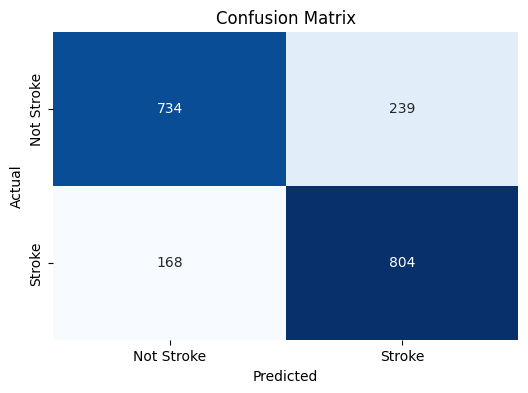


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.81      0.75      0.78       973
      Stroke       0.77      0.83      0.80       972

    accuracy                           0.79      1945
   macro avg       0.79      0.79      0.79      1945
weighted avg       0.79      0.79      0.79      1945

ROC-AUC: 0.8595018165361891


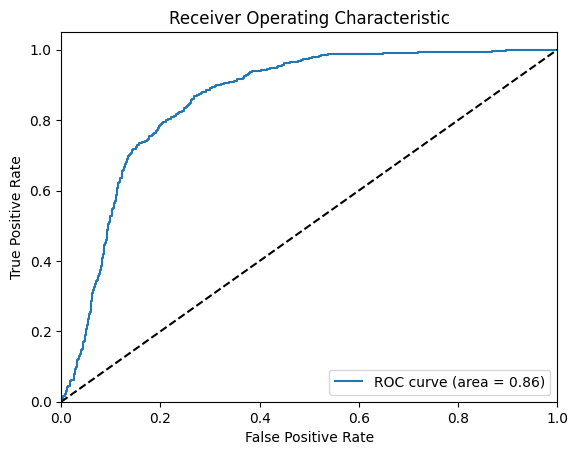

PR AUC: 0.7955621397047961


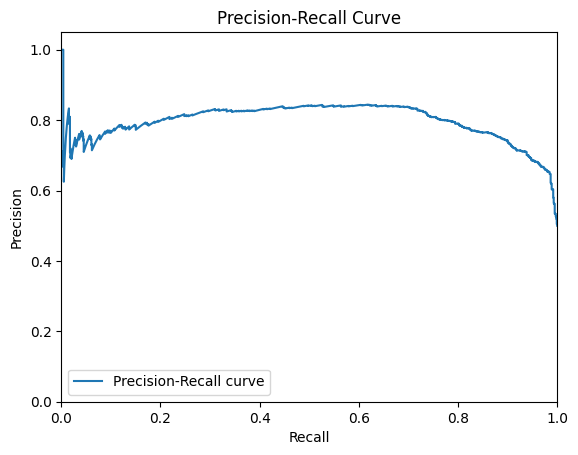

  8%|▊         | 1/13 [00:00<00:04,  2.68it/s]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)



Confusion Matrix:
 [[807 166]
 [ 20 952]]


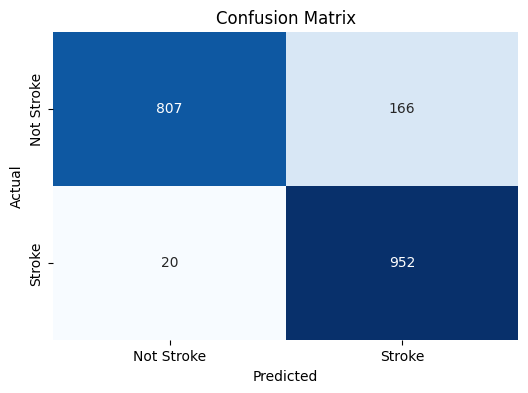


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.98      0.83      0.90       973
      Stroke       0.85      0.98      0.91       972

    accuracy                           0.90      1945
   macro avg       0.91      0.90      0.90      1945
weighted avg       0.91      0.90      0.90      1945

ROC-AUC: 0.9595038255110198


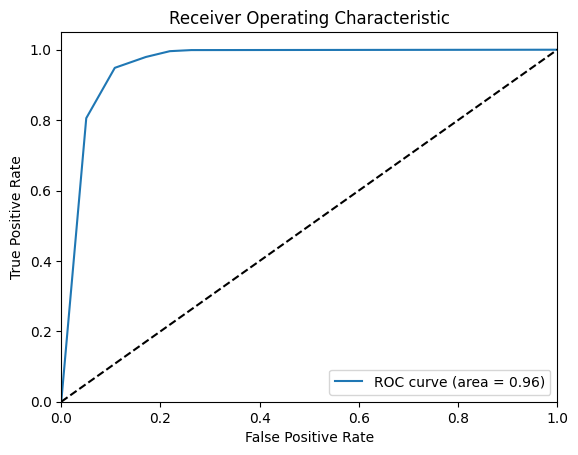

PR AUC: 0.929228613025147


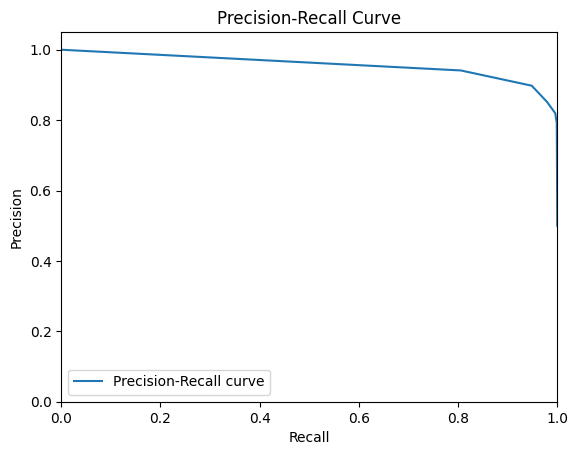

 15%|█▌        | 2/13 [00:01<00:09,  1.14it/s]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Confusion Matrix:
 [[749 224]
 [110 862]]


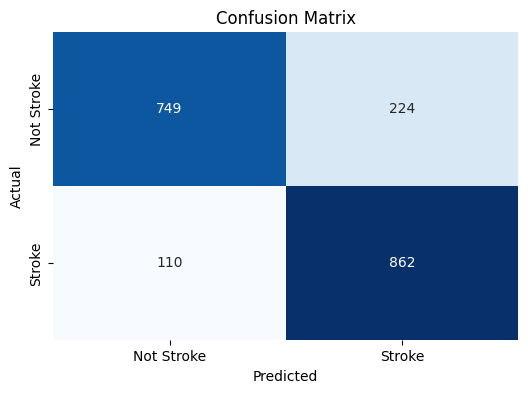


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.87      0.77      0.82       973
      Stroke       0.79      0.89      0.84       972

    accuracy                           0.83      1945
   macro avg       0.83      0.83      0.83      1945
weighted avg       0.83      0.83      0.83      1945

ROC-AUC: 0.9030616776420134


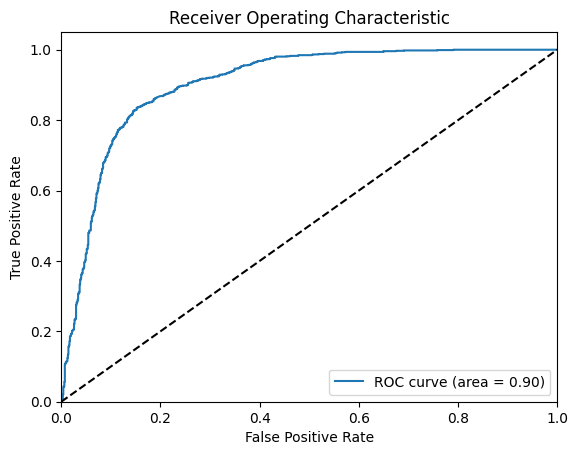

PR AUC: 0.8692017889806585


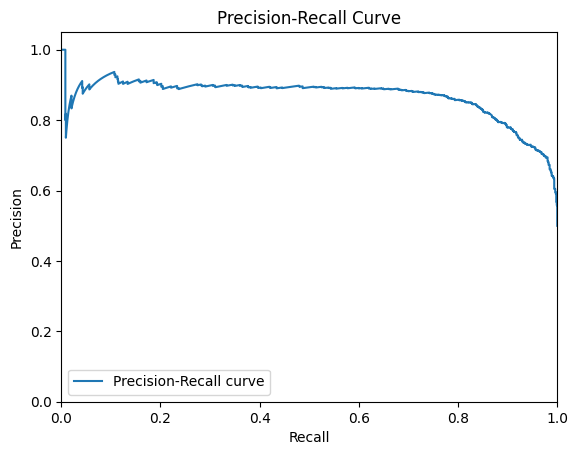

 23%|██▎       | 3/13 [00:12<00:52,  5.27s/it]


Confusion Matrix:
 [[862 111]
 [ 90 882]]


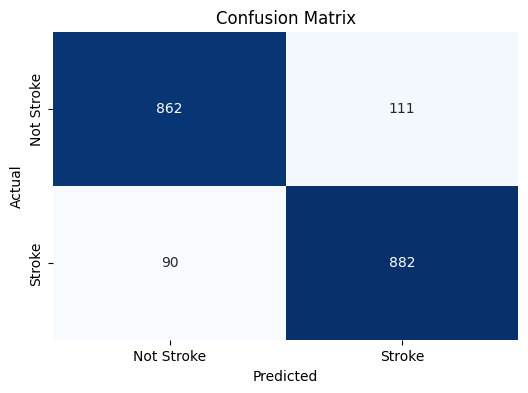


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.91      0.89      0.90       973
      Stroke       0.89      0.91      0.90       972

    accuracy                           0.90      1945
   macro avg       0.90      0.90      0.90      1945
weighted avg       0.90      0.90      0.90      1945

ROC-AUC: 0.8966636214837653


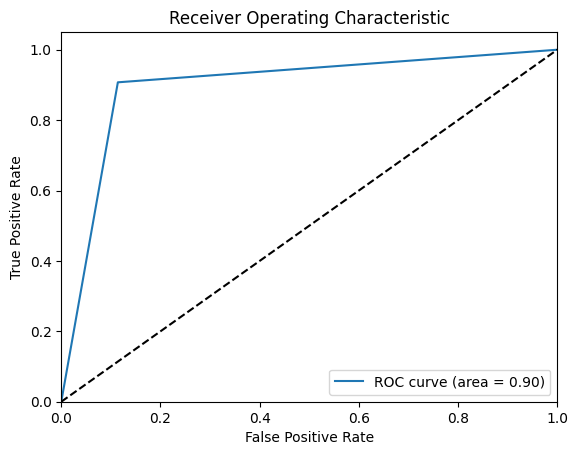

PR AUC: 0.8522476530227445


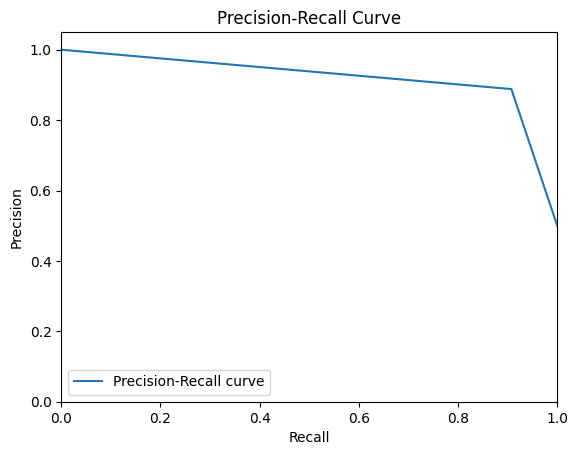

 31%|███       | 4/13 [00:12<00:30,  3.34s/it]


Confusion Matrix:
 [[712 261]
 [193 779]]


c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


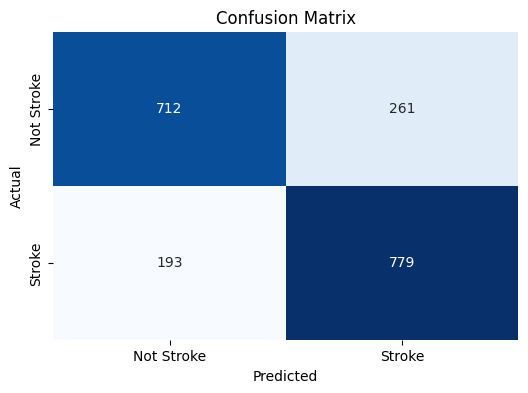


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.79      0.73      0.76       973
      Stroke       0.75      0.80      0.77       972

    accuracy                           0.77      1945
   macro avg       0.77      0.77      0.77      1945
weighted avg       0.77      0.77      0.77      1945

ROC-AUC: 0.8364546458071638


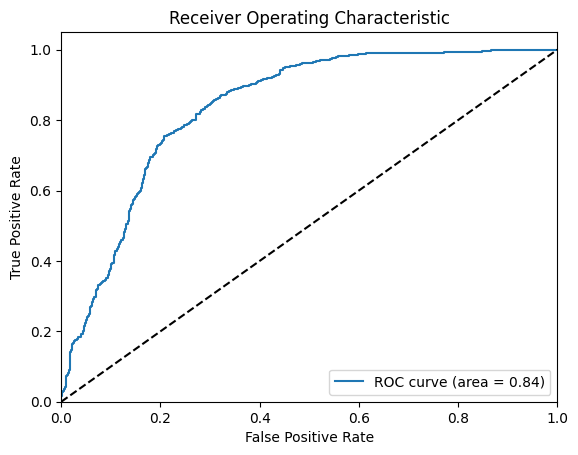

PR AUC: 0.7918532682381934


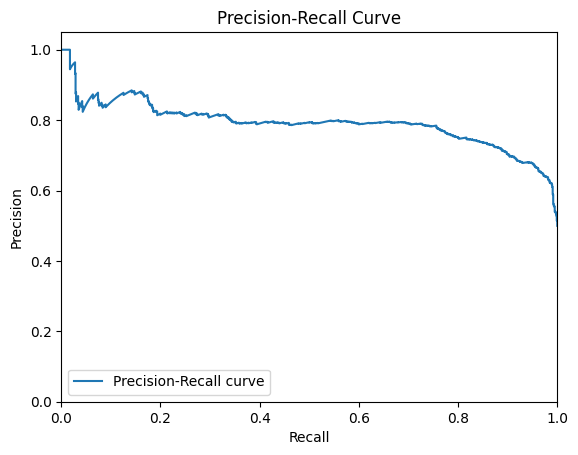

 38%|███▊      | 5/13 [00:12<00:17,  2.25s/it]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Confusion Matrix:
 [[924  49]
 [ 36 936]]


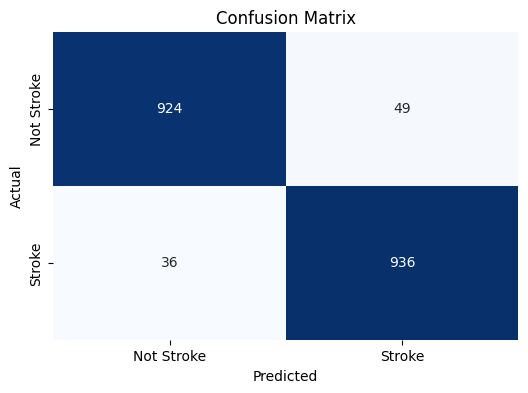


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.96      0.95      0.96       973
      Stroke       0.95      0.96      0.96       972

    accuracy                           0.96      1945
   macro avg       0.96      0.96      0.96      1945
weighted avg       0.96      0.96      0.96      1945

ROC-AUC: 0.9916104153714066


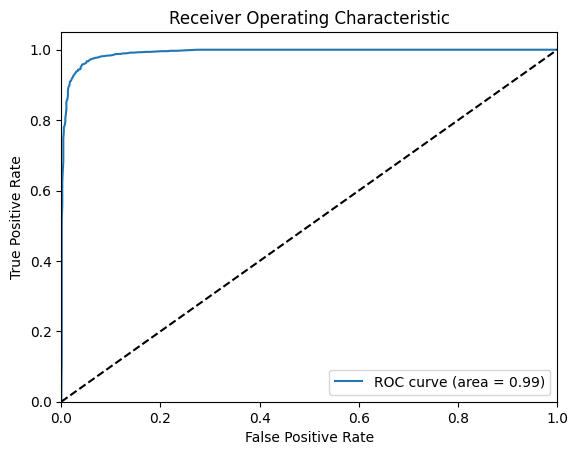

PR AUC: 0.9894171496076261


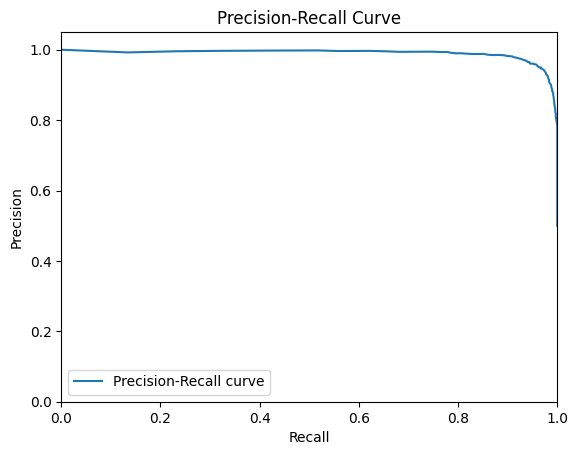

 46%|████▌     | 6/13 [00:14<00:13,  1.95s/it]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Confusion Matrix:
 [[921  52]
 [ 17 955]]


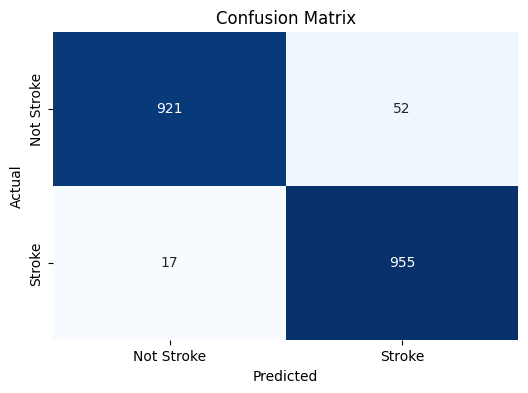


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.98      0.95      0.96       973
      Stroke       0.95      0.98      0.97       972

    accuracy                           0.96      1945
   macro avg       0.97      0.96      0.96      1945
weighted avg       0.97      0.96      0.96      1945

ROC-AUC: 0.9943257034583973


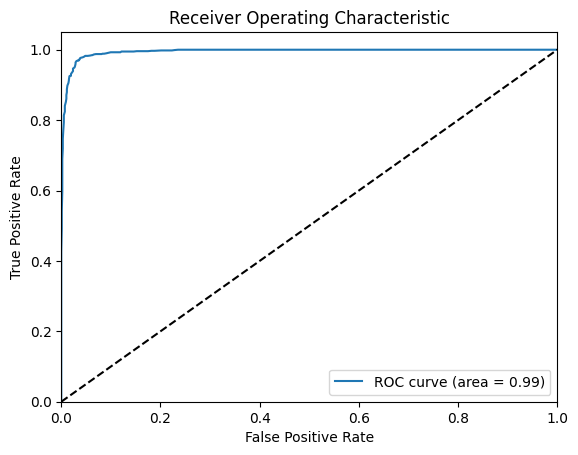

PR AUC: 0.9937456634511729


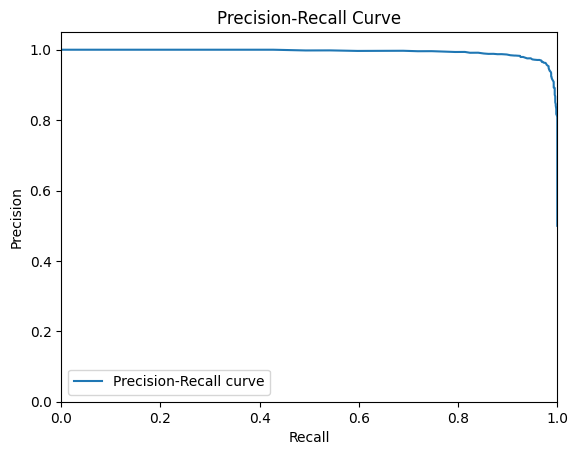

 54%|█████▍    | 7/13 [00:15<00:09,  1.61s/it]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Confusion Matrix:
 [[730 243]
 [106 866]]


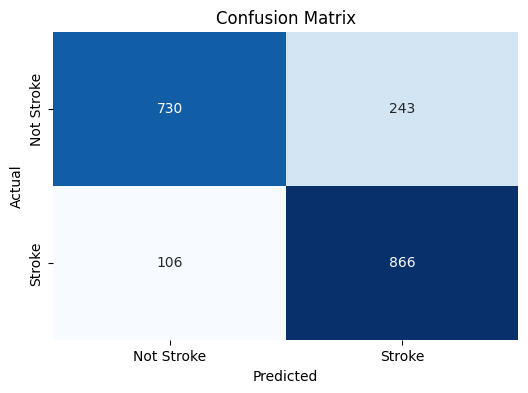


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.87      0.75      0.81       973
      Stroke       0.78      0.89      0.83       972

    accuracy                           0.82      1945
   macro avg       0.83      0.82      0.82      1945
weighted avg       0.83      0.82      0.82      1945

ROC-AUC: 0.9108200212316919


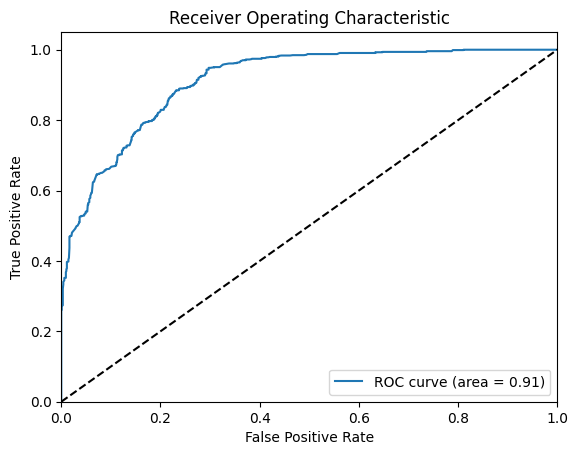

PR AUC: 0.9102276292893241


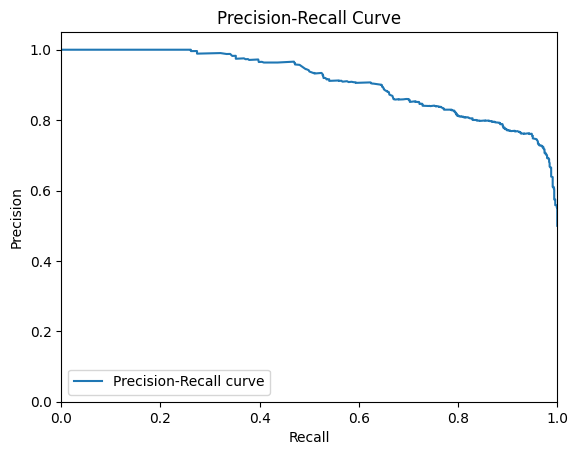

 62%|██████▏   | 8/13 [00:15<00:06,  1.30s/it]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Confusion Matrix:
 [[861 112]
 [ 86 886]]


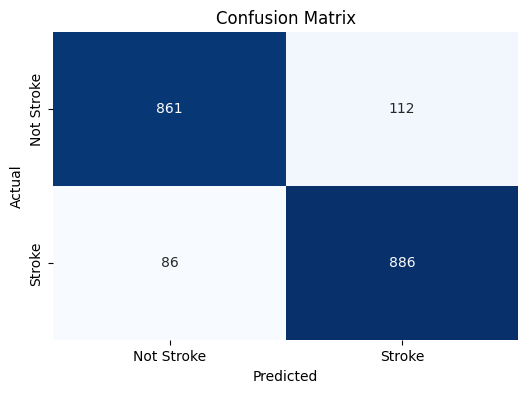


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.91      0.88      0.90       973
      Stroke       0.89      0.91      0.90       972

    accuracy                           0.90      1945
   macro avg       0.90      0.90      0.90      1945
weighted avg       0.90      0.90      0.90      1945

ROC-AUC: 0.968315294854064


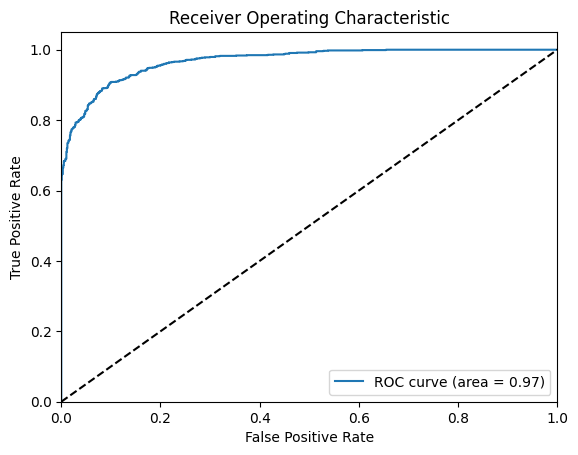

PR AUC: 0.9716954063061649


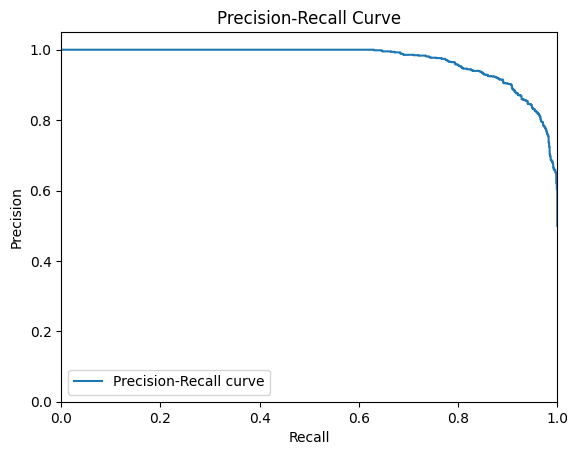

 69%|██████▉   | 9/13 [00:17<00:05,  1.36s/it]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Confusion Matrix:
 [[929  44]
 [ 46 926]]


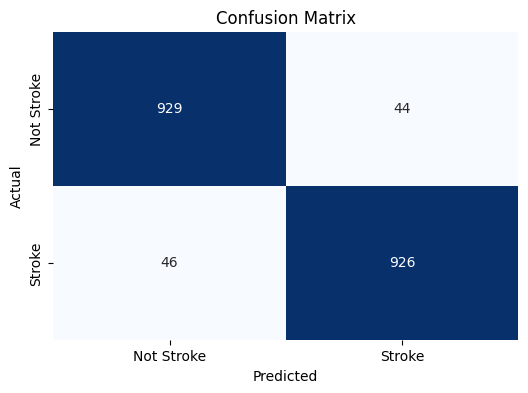


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.95      0.95      0.95       973
      Stroke       0.95      0.95      0.95       972

    accuracy                           0.95      1945
   macro avg       0.95      0.95      0.95      1945
weighted avg       0.95      0.95      0.95      1945

ROC-AUC: 0.9910198825066929


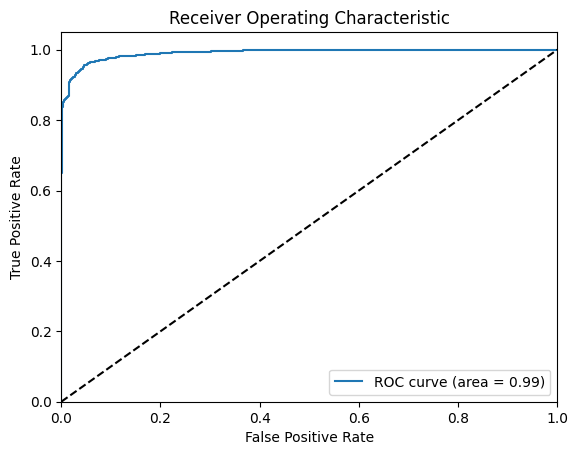

PR AUC: 0.9918028686117805


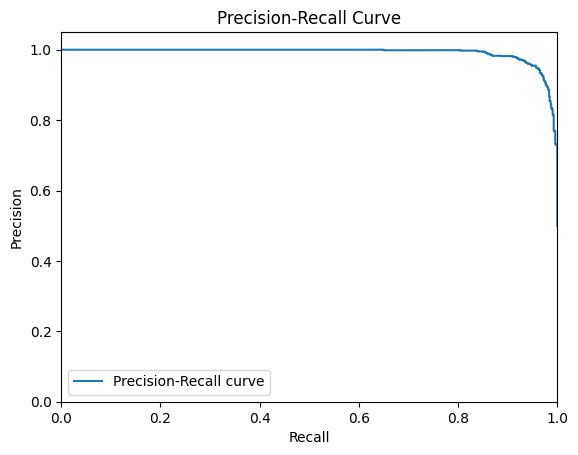

 77%|███████▋  | 10/13 [00:18<00:03,  1.22s/it]c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:20:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion Matrix:
 [[941  32]
 [ 46 926]]


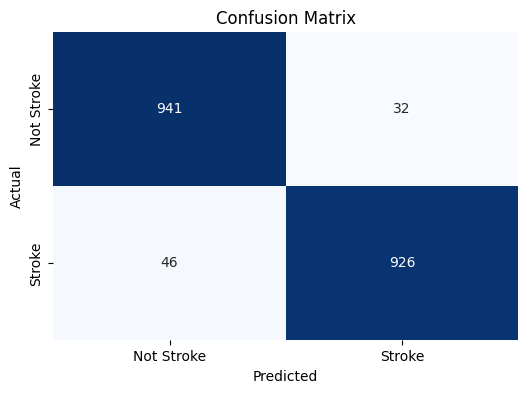


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.95      0.97      0.96       973
      Stroke       0.97      0.95      0.96       972

    accuracy                           0.96      1945
   macro avg       0.96      0.96      0.96      1945
weighted avg       0.96      0.96      0.96      1945

ROC-AUC: 0.9913994730141814


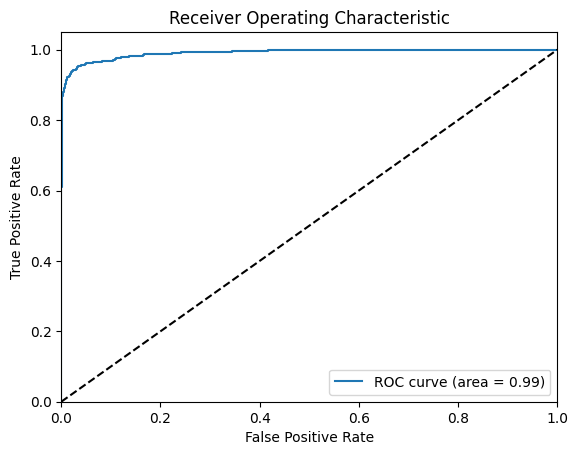

PR AUC: 0.9924410944746621


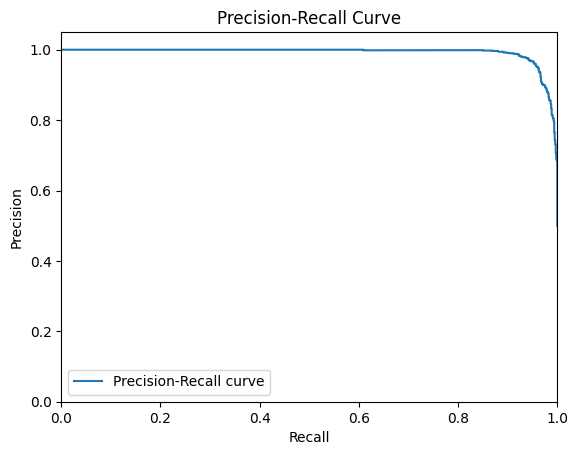

 85%|████████▍ | 11/13 [00:18<00:02,  1.04s/it]


Confusion Matrix:
 [[945  28]
 [ 52 920]]


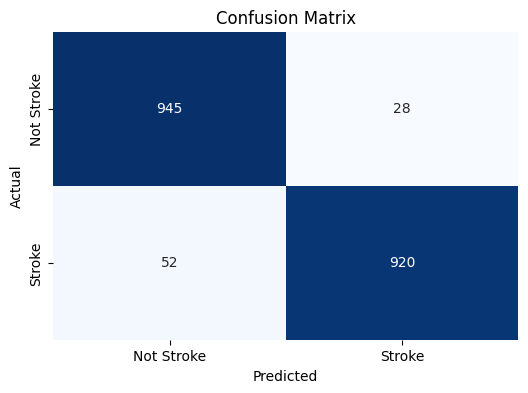


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.95      0.97      0.96       973
      Stroke       0.97      0.95      0.96       972

    accuracy                           0.96      1945
   macro avg       0.96      0.96      0.96      1945
weighted avg       0.96      0.96      0.96      1945

ROC-AUC: 0.993348178599977


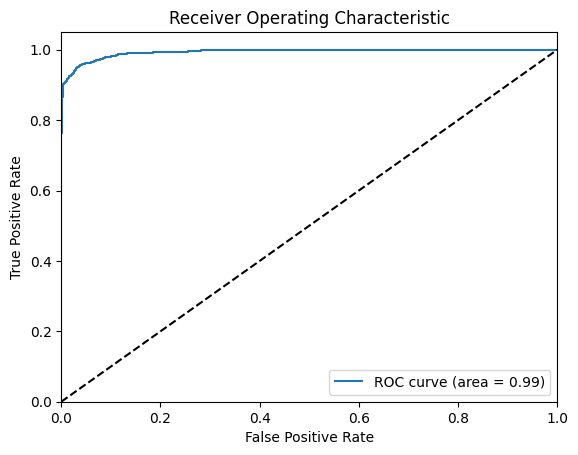

PR AUC: 0.9939708732534211


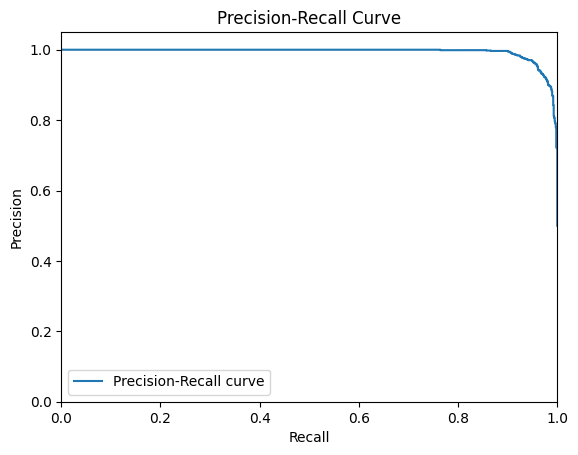

 92%|█████████▏| 12/13 [00:24<00:02,  2.59s/it]

[LightGBM] [Info] Number of positive: 3889, number of negative: 3888
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1580
[LightGBM] [Info] Number of data points in the train set: 7777, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500064 -> initscore=0.000257
[LightGBM] [Info] Start training from score 0.000257


c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Confusion Matrix:
 [[946  27]
 [ 52 920]]


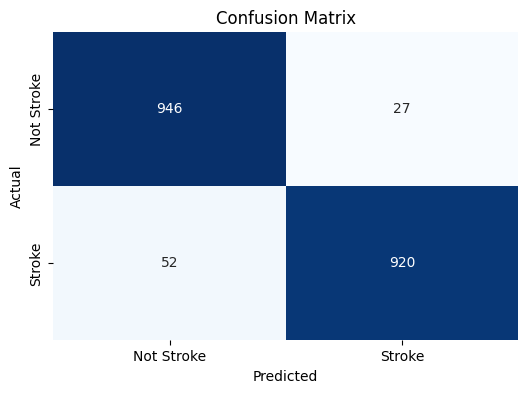


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.95      0.97      0.96       973
      Stroke       0.97      0.95      0.96       972

    accuracy                           0.96      1945
   macro avg       0.96      0.96      0.96      1945
weighted avg       0.96      0.96      0.96      1945

ROC-AUC: 0.9920994421394103


c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


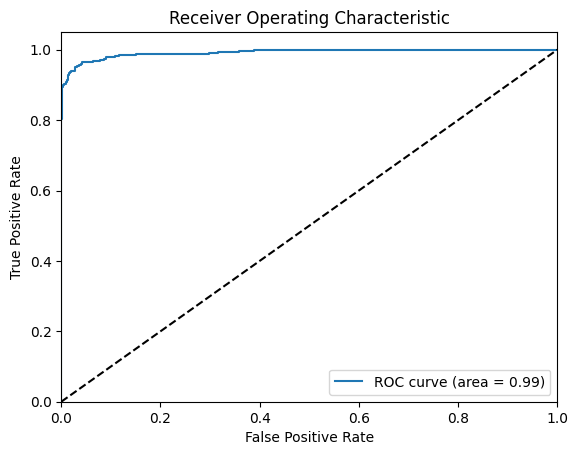

PR AUC: 0.9932483021778635


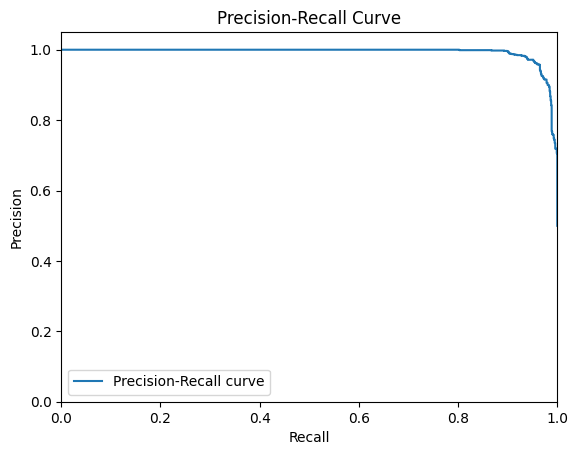

100%|██████████| 13/13 [00:25<00:00,  1.96s/it]


In [ ]:
results = {}

for name, model in tqdm(models.items()):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    
    

    cm = confusion_matrix(y_test, test_pred)
    print("\nConfusion Matrix:\n", cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',cbar=False,
                xticklabels=['Not Stroke','Stroke']
                ,yticklabels=['Not Stroke','Stroke'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # Full classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_pred,target_names=['Not Stroke','Stroke'],zero_division=0))

    y_pred_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print("ROC-AUC:", roc_auc)

    # ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    pr_auc = average_precision_score(y_test, y_pred_prob)
    print("PR AUC:", pr_auc)

    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred),
        "ROC-AUC": roc_auc,
        "PR AUC": pr_auc

    }
    

# Voting Classification

c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:20:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion Matrix:
 [[857 116]
 [ 49 923]]


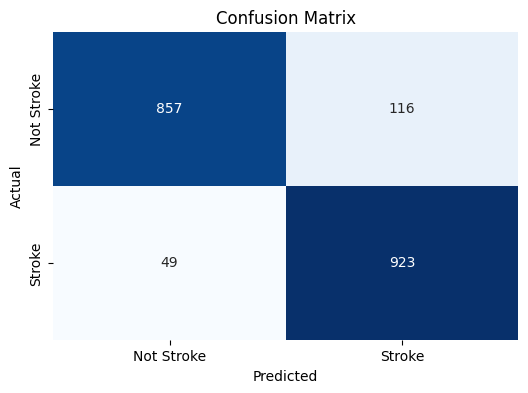


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.95      0.88      0.91       973
      Stroke       0.89      0.95      0.92       972

    accuracy                           0.92      1945
   macro avg       0.92      0.92      0.92      1945
weighted avg       0.92      0.92      0.92      1945

ROC-AUC: 0.9771960209610089


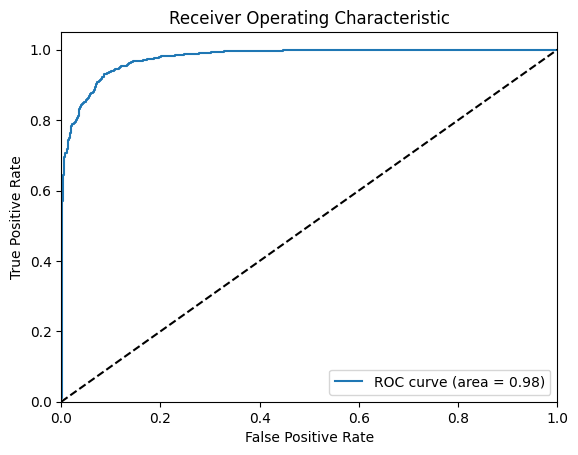

PR AUC: 0.9745828365555989


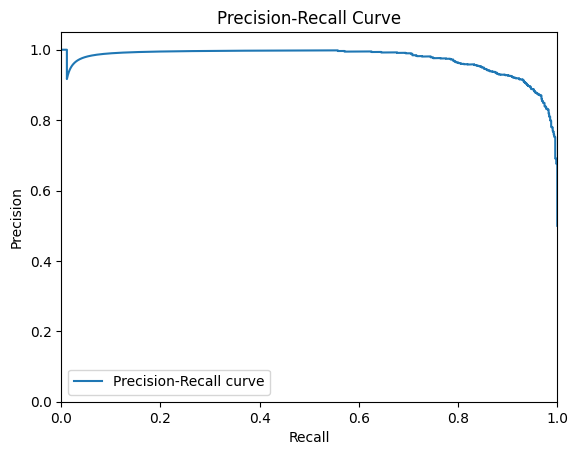

In [ ]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", models["Logistic Regression"]),
        ("rf", models["Random Forest"]),
        ("nb", models["Naive Bayes"]),
        ("xgb", models["XGBoost"]),
    ],
    voting="soft" # voting='hard' / voting='soft', weights=[2, 1, 2,1]
)

voting_model.fit(X_train, y_train)
voting_train_pred = voting_model.predict(X_train)
voting_test_pred = voting_model.predict(X_test)


cm = confusion_matrix(y_test, voting_test_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',cbar=False,
             xticklabels=['Not Stroke','Stroke']
            ,yticklabels=['Not Stroke','Stroke'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, voting_test_pred,target_names=['Not Stroke','Stroke'],zero_division=0))

y_pred_prob = voting_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

pr_auc = average_precision_score(y_test, y_pred_prob)
print("PR AUC:", pr_auc)

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

results["Voting Classifier"] = {
    "Train Accuracy": accuracy_score(y_train, voting_train_pred),
    "Test Accuracy": accuracy_score(y_test, voting_test_pred),
    "Train Precision": precision_score(y_train, voting_train_pred),
    "Test Precision": precision_score(y_test, voting_test_pred),
    "Train Recall": recall_score(y_train, voting_train_pred),
    "Test Recall": recall_score(y_test, voting_test_pred),
    "Train F1 Score": f1_score(y_train, voting_train_pred),
    "Test F1 Score": f1_score(y_test, voting_test_pred),
    "Train Balanced Accuracy": balanced_accuracy_score(y_train, voting_train_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, voting_test_pred),
    "ROC-AUC": roc_auc,
    "PR AUC": pr_auc
}

# Stacking Classifier

c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:20:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "max_iter" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifie


Confusion Matrix:
 [[944  29]
 [ 50 922]]


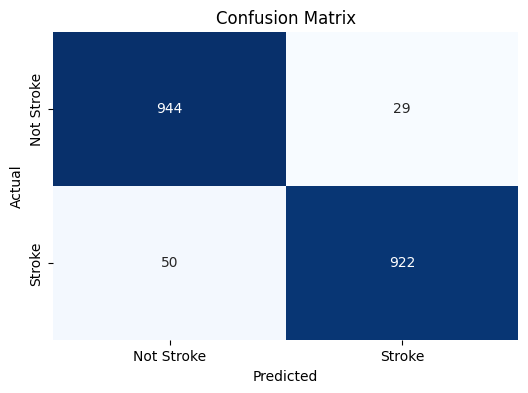


Classification Report:

              precision    recall  f1-score   support

  Not Stroke       0.95      0.97      0.96       973
      Stroke       0.97      0.95      0.96       972

    accuracy                           0.96      1945
   macro avg       0.96      0.96      0.96      1945
weighted avg       0.96      0.96      0.96      1945

ROC-AUC: 0.9944287955878682


c:\Users\MG magic\anaconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


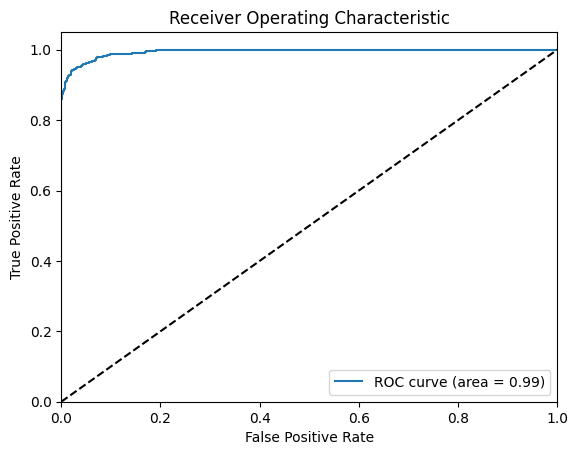

PR AUC: 0.9947704873666583


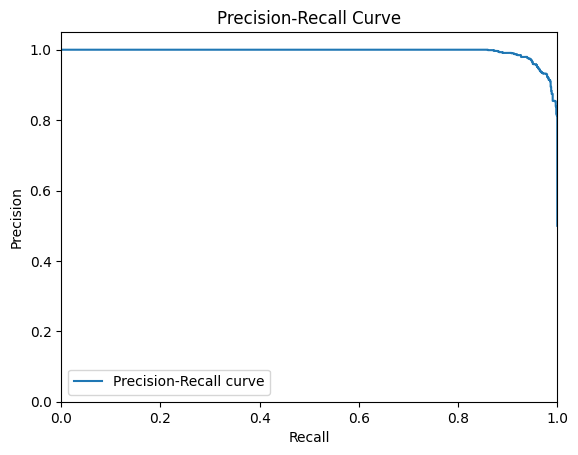

In [ ]:
stack_auto = StackingClassifier(
    estimators=[
        ("lr", models["Logistic Regression"]),
        ("rf", models["Random Forest"]),
        ("nb", models["Naive Bayes"]),
        ("lgbm", models["LightGBM"]),

        
    ],
    final_estimator=XGBClassifier(max_iter=2000),
    stack_method="predict_proba",   # best for classification usually
    n_jobs=-1
)

# Train
stack_auto.fit(X_train, y_train)

# Predictions
stack_auto_train_pred = stack_auto.predict(X_train)
stack_auto_test_pred  = stack_auto.predict(X_test)

cm = confusion_matrix(y_test, stack_auto_test_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',cbar=False,
             xticklabels=['Not Stroke','Stroke']
            ,yticklabels=['Not Stroke','Stroke'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, stack_auto_test_pred,target_names=['Not Stroke','Stroke'],zero_division=0))

y_pred_prob = stack_auto.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

pr_auc = average_precision_score(y_test, y_pred_prob)
print("PR AUC:", pr_auc)

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

results["Stacking Classifier "] = {
    "Train Accuracy": accuracy_score(y_train, stack_auto_train_pred),
    "Test Accuracy": accuracy_score(y_test, stack_auto_test_pred),
    "Train Precision": precision_score(y_train, stack_auto_train_pred),
    "Test Precision": precision_score(y_test, stack_auto_test_pred),
    "Train Recall": recall_score(y_train, stack_auto_train_pred),
    "Test Recall": recall_score(y_test, stack_auto_test_pred),
    "Train F1 Score": f1_score(y_train, stack_auto_train_pred),
    "Test F1 Score": f1_score(y_test, stack_auto_test_pred),
    "Train Balanced Accuracy": balanced_accuracy_score(y_train, stack_auto_train_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, stack_auto_test_pred),
    "ROC-AUC": roc_auc,
    "PR AUC": pr_auc
}

In [75]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)

In [76]:
results_df

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy
Extra Trees,1.000000,0.964524,1.000000,0.948361,1.000000,0.982510,1.000000,0.965134,1.000000,0.964534
XGBoost,0.995371,0.959897,0.996393,0.966597,0.994343,0.952675,0.995367,0.959585,0.995371,0.959893
Stacking Classifier,0.993957,0.959383,0.993070,0.969506,0.994857,0.948560,0.993963,0.958918,0.993956,0.959377
LightGBM,0.984313,0.959383,0.988586,0.971489,0.979943,0.946502,0.984246,0.958833,0.984313,0.959376
CatBoost,0.982255,0.958869,0.987523,0.970464,0.976858,0.946502,0.982161,0.958333,0.982256,0.958863
Random Forest,1.000000,0.956298,1.000000,0.950254,1.000000,0.962963,1.000000,0.956566,1.000000,0.956302
Hist Gradient Boosting,0.978398,0.953728,0.976685,0.954639,0.980201,0.952675,0.978439,0.953656,0.978398,0.953727
Voting Classifier,0.958210,0.915167,0.939566,0.888354,0.979429,0.949588,0.959083,0.917951,0.958207,0.915185
KNN,0.933651,0.904370,0.888326,0.851521,0.992029,0.979424,0.937318,0.911005,0.933643,0.904409
Gradient Boosting,0.904976,0.898201,0.892377,0.887776,0.921059,0.911523,0.906491,0.899492,0.904974,0.898207


<Axes: >

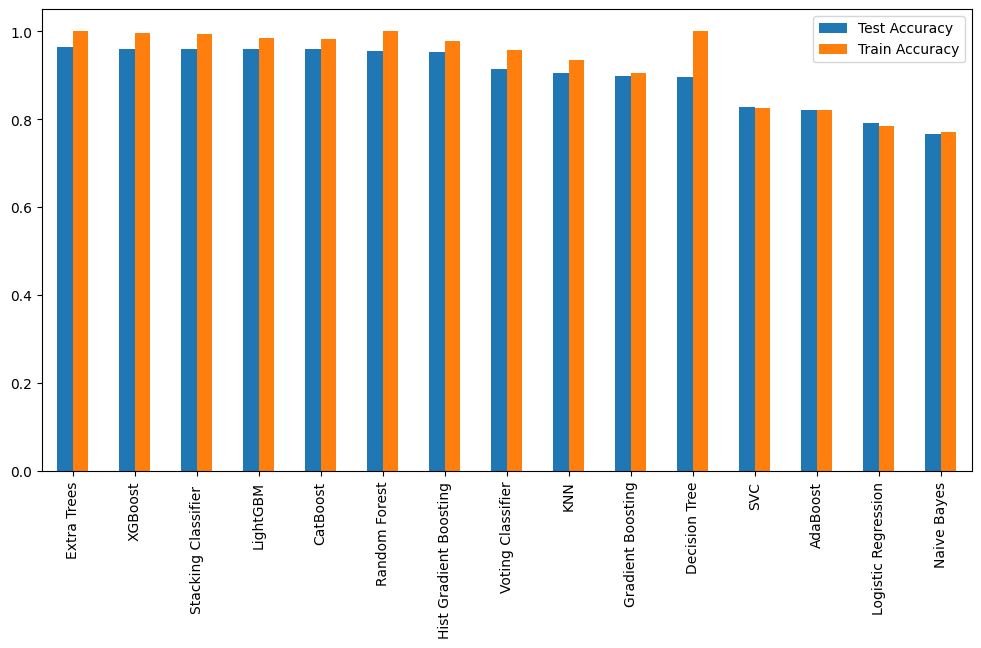

In [77]:
results_df[["Test Accuracy", "Train Accuracy"]].plot.bar(figsize=(12,6))

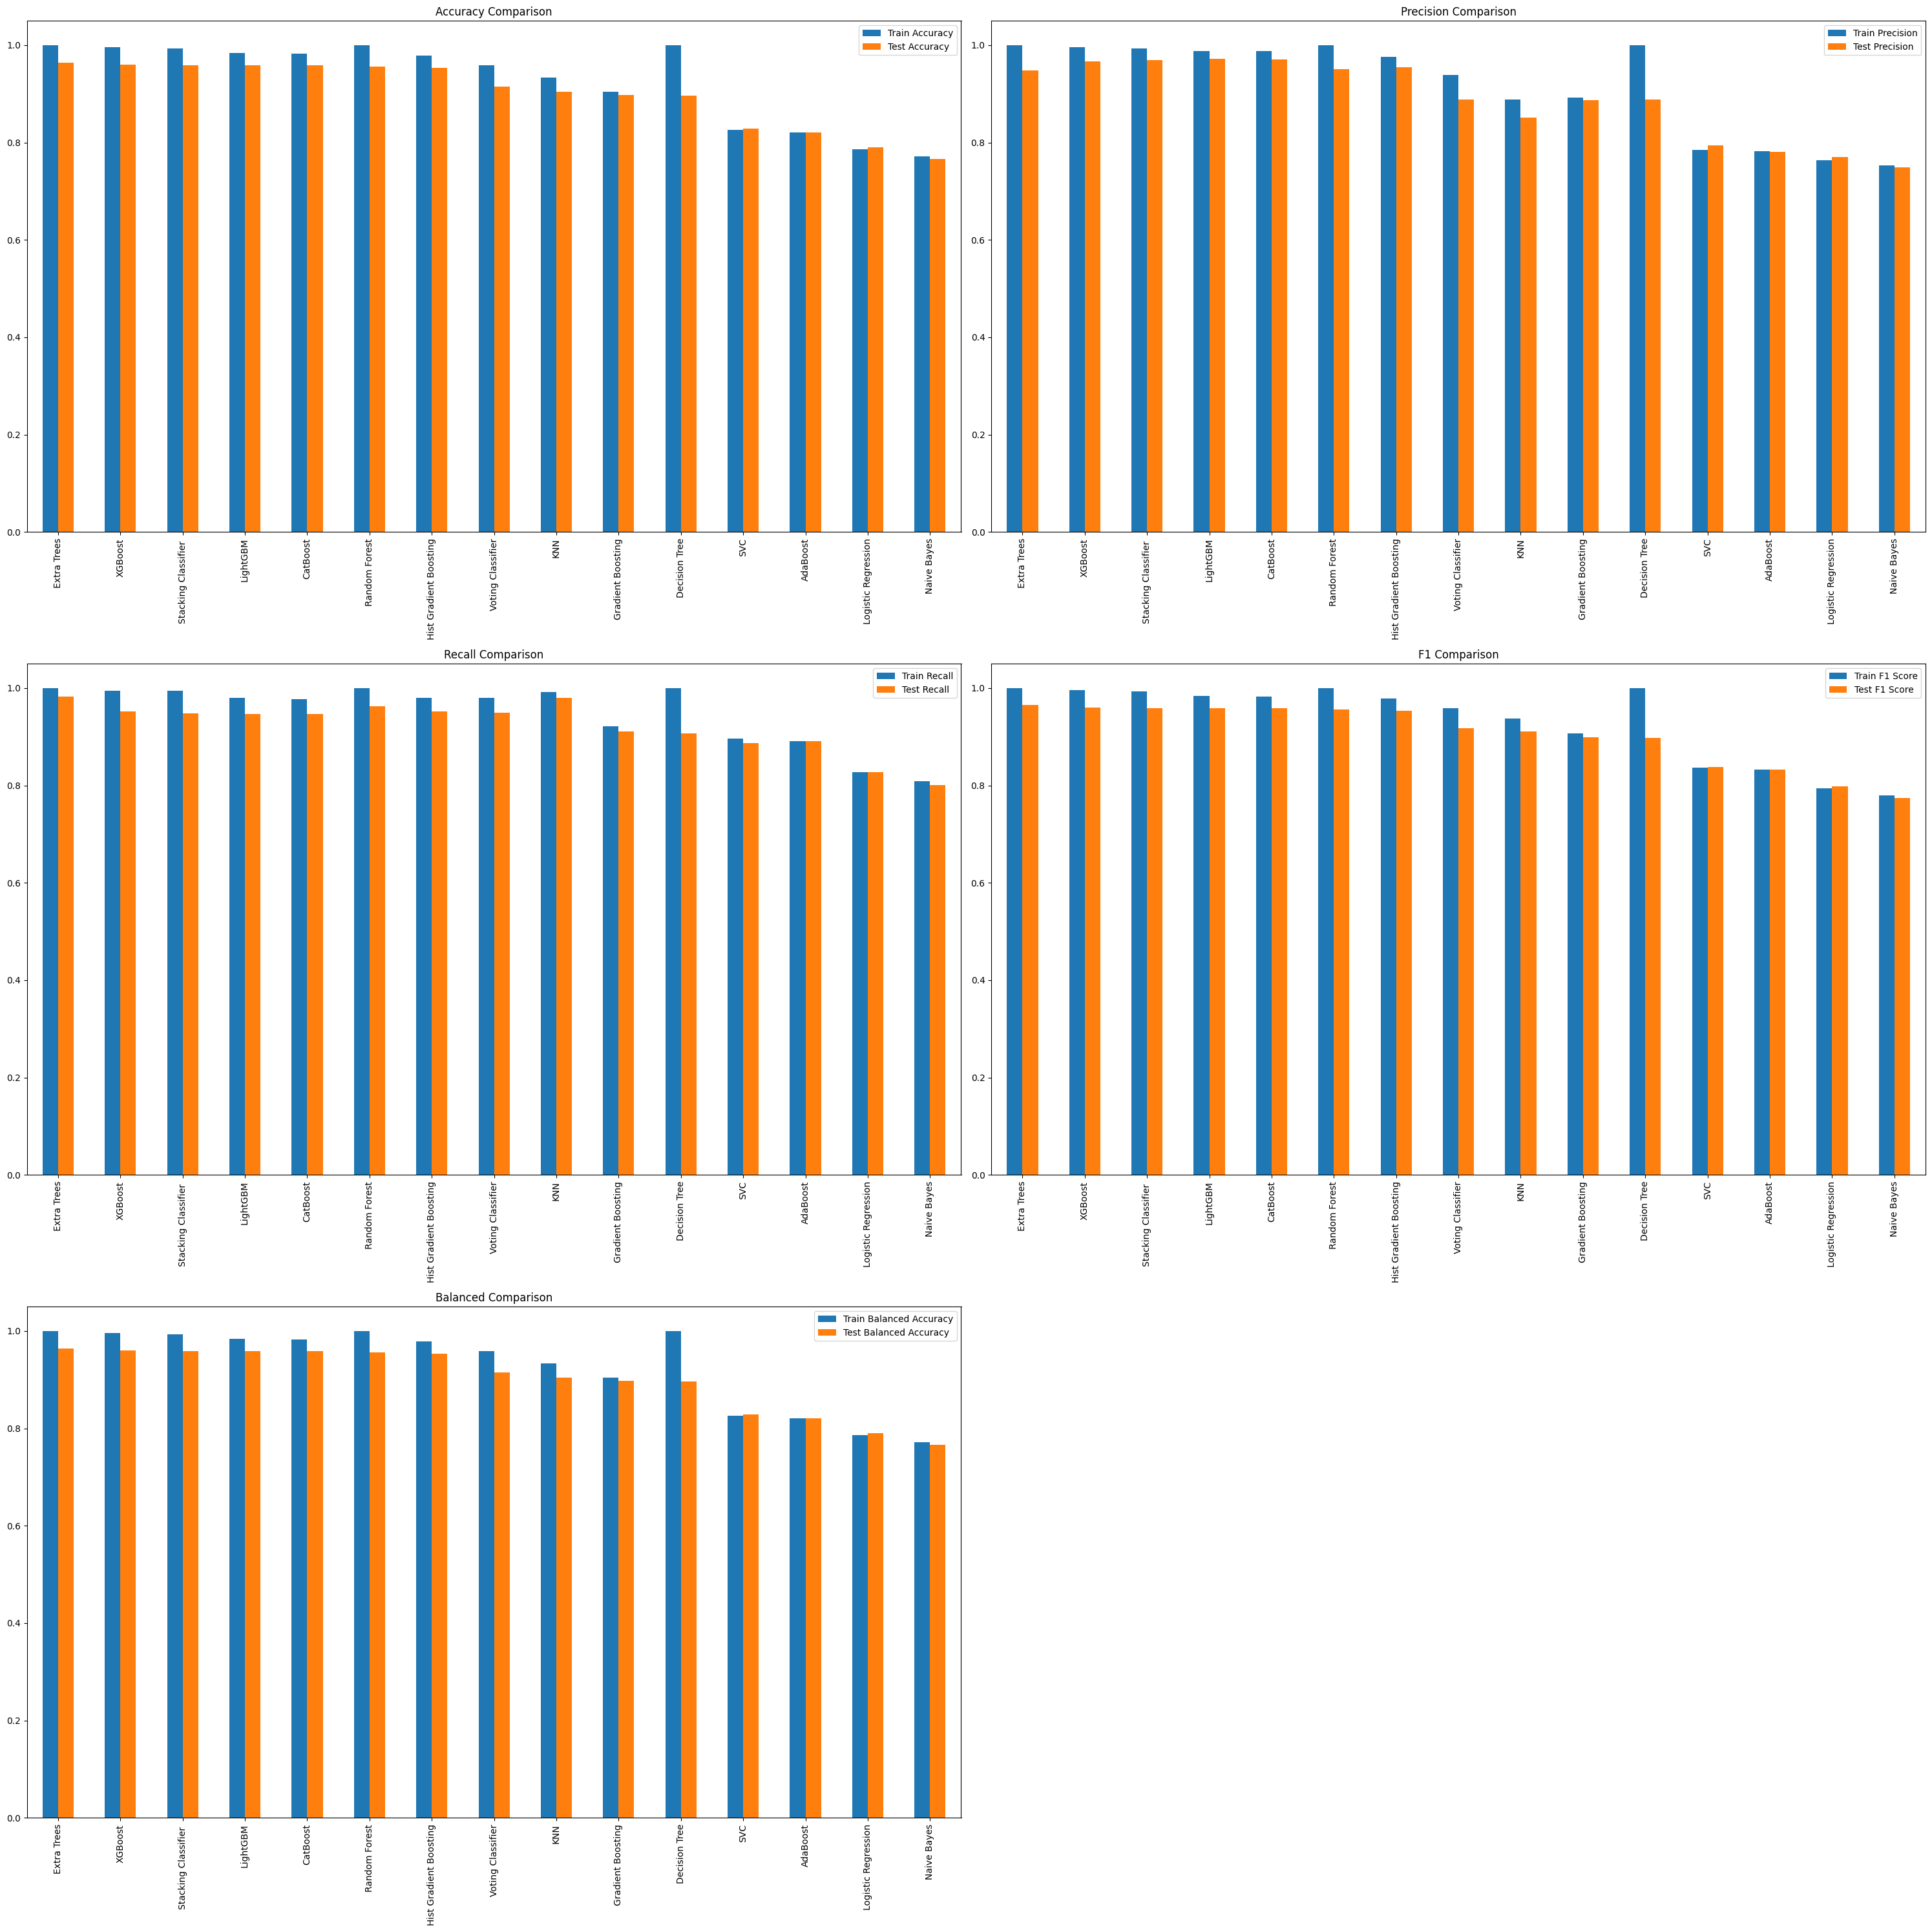

In [82]:
cols = [
    ['Train Accuracy', 'Test Accuracy'],
    ['Train Precision', 'Test Precision'],
    ['Train Recall', 'Test Recall'],
    ['Train F1 Score', 'Test F1 Score'],
    ["Train Balanced Accuracy", "Test Balanced Accuracy"]
]

plt.figure(figsize=(30,30))

for i, col in enumerate(cols):
    ax = plt.subplot(3, 2, i+1)   
    results_df[col].plot.bar(ax=ax)   
    ax.set_title(col[0].split(" ")[1] + ' Comparison')

plt.tight_layout()
plt.show()